# AuditFlow — Load & Performance Testing

A configurable load-testing notebook for the AuditFlow audit-logging pipeline.

## How to use

1. **Start the stack**: `just up` — wait until `just status` shows all containers healthy.
2. **Run §0 – §6 once** per session (infrastructure cells).
3. **Set `ACTIVE_PROFILE`** in **§2**, then re-run **§7** for each test.
4. **Charts appear automatically** after every run. Call `compare_runs()` in **§8** at any time.

## Profiles

| Profile | Goal |
|---|---|
| `slow_stream` | Simulate a production audit cadence at a controlled rate |
| `fast_heavy` | Maximum concurrency + large payloads — find memory / bandwidth ceiling |
| `sustained_moderate` | Always-on baseline threads + foreground test load |
| `ramp_saturation` | +1 thread every 30 s — find the saturation point automatically |
| `spike` | Quiet → burst → quiet cycles — test recovery behaviour |
| `soak` | 1-hour throttled run — expose GC drift and memory leaks |
| `payload_variable` | Random payload size per request — realistic mixed-event stream |
| `count_exact` | Exactly N events then stop — pipeline-level verification |

## Prerequisites

```bash
just up       # build JAR, all images, start the stack
just status   # wait until all containers show "healthy"
```


## §0 — Imports & Endpoint

Run once per session.

In [1]:
%matplotlib inline

import requests
import threading
import time
import uuid
import math
import json
import random
import sys
from dataclasses import dataclass, field
from datetime import datetime, timezone
from collections import defaultdict, deque

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         9,
})

# ── Endpoint ───────────────────────────────────────────────────
BACKEND      = "http://localhost:8080/api/v1/audit/publish"
ACTUATOR     = "http://localhost:8080/actuator"
HTTP_TIMEOUT = 10  # per-request timeout (seconds)

# ── Event template ─────────────────────────────────────────────
TENANT_ID     = "LOAD-TEST"
SOURCE_SYSTEM = "load-test-runner"

print("Imports ready.")

Imports ready.


## §1 — Profile Definitions

Run once per session. Add or edit profiles here.

In [2]:
PROFILES: dict[str, dict] = {

    # ── 1. Continuous slow stream ──────────────────────────────
    "slow_stream": {
        "description":          "Continuous low-rate stream — simulates a production audit cadence",
        "num_threads":          2,
        "ramp_up_seconds":      2,
        "duration_seconds":     300,
        "total_events":         0,
        "payload_size":         "small",
        "rate_limit_rps":       10,     # per thread  → ~20 req/s total
        "background_threads":   0,
        "background_rate_rps":  0,
    },

    # ── 2. Fast but heavy ──────────────────────────────────────
    "fast_heavy": {
        "description":          "Max concurrency, large payloads — find memory / bandwidth ceiling",
        "num_threads":          20,
        "ramp_up_seconds":      5,
        "duration_seconds":     120,
        "total_events":         0,
        "payload_size":         "large",
        "rate_limit_rps":       0,      # unlimited
        "background_threads":   0,
        "background_rate_rps":  0,
    },

    # ── 3. Sustained moderate with permanent baseline load ─────
    "sustained_moderate": {
        "description":          "2 always-on background threads + 5 foreground threads, medium payload",
        "num_threads":          5,
        "ramp_up_seconds":      3,
        "duration_seconds":     600,
        "total_events":         0,
        "payload_size":         "medium",
        "rate_limit_rps":       0,
        "background_threads":   2,      # always-on, rate-limited
        "background_rate_rps":  15,     # per background thread → 30 req/s baseline
    },

    # ── 4. Ramp to saturation ──────────────────────────────────
    "ramp_saturation": {
        "description":          "+1 thread every 30 s until p99 > 100 ms or 30 threads reached",
        "num_threads":          30,
        "ramp_up_seconds":      0,
        "duration_seconds":     0,
        "total_events":         0,
        "payload_size":         "small",
        "rate_limit_rps":       0,
        "background_threads":   0,
        "background_rate_rps":  0,
        "step_interval_seconds": 30,
        "saturation_p99_ms":    100,
    },

    # ── 5. Spike test ──────────────────────────────────────────
    "spike": {
        "description":          "Quiet baseline → 15-thread burst → quiet, 3 cycles",
        "num_threads":          15,
        "ramp_up_seconds":      1,
        "duration_seconds":     0,
        "total_events":         0,
        "payload_size":         "small",
        "rate_limit_rps":       0,
        "background_threads":   2,
        "background_rate_rps":  5,
        "spike_quiet_seconds":  60,
        "spike_burst_seconds":  15,
        "spike_cycles":         3,
    },

    # ── 6. Soak test ───────────────────────────────────────────
    "soak": {
        "description":          "1-hour throttled run — expose GC drift and memory leaks",
        "num_threads":          5,
        "ramp_up_seconds":      10,
        "duration_seconds":     3_600,
        "total_events":         0,
        "payload_size":         "small",
        "rate_limit_rps":       40,
        "background_threads":   0,
        "background_rate_rps":  0,
    },

    # ── 7. Variable payload ────────────────────────────────────
    "payload_variable": {
        "description":          "Random payload per request (70 % small / 25 % medium / 5 % large)",
        "num_threads":          5,
        "ramp_up_seconds":      2,
        "duration_seconds":     300,
        "total_events":         0,
        "payload_size":         "variable",
        "rate_limit_rps":       0,
        "background_threads":   0,
        "background_rate_rps":  0,
    },

    # ── 8. Exact event count ───────────────────────────────────
    "count_exact": {
        "description":          "Exactly 10,000 events then stop — pipeline-level verification",
        "num_threads":          10,
        "ramp_up_seconds":      2,
        "duration_seconds":     0,
        "total_events":         10_000,
        "payload_size":         "small",
        "rate_limit_rps":       0,
        "background_threads":   0,
        "background_rate_rps":  0,
    },
}

print(f"Profiles defined: {', '.join(PROFILES)}")

Profiles defined: slow_stream, fast_heavy, sustained_moderate, ramp_saturation, spike, soak, payload_variable, count_exact


## §2 — Profile Selector

Change `ACTIVE_PROFILE` and re-run this cell before each test.

In [3]:
# ── Change this line to switch profiles ────────────────────────
# Options: slow_stream | fast_heavy | sustained_moderate
#          ramp_saturation | spike | soak | payload_variable | count_exact
ACTIVE_PROFILE = "soak"

# ── Load & unpack ───────────────────────────────────────────────
cfg = PROFILES[ACTIVE_PROFILE]

NUM_THREADS          = cfg["num_threads"]
RAMP_UP_SECONDS      = cfg["ramp_up_seconds"]
DURATION_SECONDS     = cfg["duration_seconds"]
TOTAL_EVENTS         = cfg["total_events"]
PAYLOAD_SIZE         = cfg["payload_size"]
RATE_LIMIT_RPS       = cfg.get("rate_limit_rps", 0)
BACKGROUND_THREADS   = cfg.get("background_threads", 0)
BACKGROUND_RATE_RPS  = cfg.get("background_rate_rps", 0)

_SELF_TERMINATING = ACTIVE_PROFILE in ("ramp_saturation", "spike")
if DURATION_SECONDS == 0 and TOTAL_EVENTS == 0 and not _SELF_TERMINATING:
    DURATION_SECONDS = 30
    print(f"⚠  Both limits are 0 — defaulting to {DURATION_SECONDS} s safety fallback")

W = 56
print("═" * W)
print(f"  Profile : {ACTIVE_PROFILE}")
print(f"  {cfg['description']}")
print("─" * W)
print(f"  Test threads    : {NUM_THREADS}")
if BACKGROUND_THREADS > 0:
    print(f"  Background      : {BACKGROUND_THREADS} × {BACKGROUND_RATE_RPS} req/s"
          f"  ({BACKGROUND_THREADS * BACKGROUND_RATE_RPS} req/s baseline)")
print(f"  Ramp-up         : {RAMP_UP_SECONDS} s")
print(f"  Duration        : {DURATION_SECONDS} s" if DURATION_SECONDS > 0
      else "  Duration        : controlled by profile logic")
if TOTAL_EVENTS > 0:
    print(f"  Event cap       : {TOTAL_EVENTS:,}")
print(f"  Payload         : {PAYLOAD_SIZE}")
if RATE_LIMIT_RPS > 0:
    print(f"  Rate limit      : {RATE_LIMIT_RPS} req/s per thread"
          f"  ({RATE_LIMIT_RPS * NUM_THREADS} req/s max)")
else:
    print(f"  Rate limit      : unlimited")
for key in ("step_interval_seconds", "saturation_p99_ms",
            "spike_quiet_seconds", "spike_burst_seconds", "spike_cycles"):
    if key in cfg:
        print(f"  {key.replace('_', ' ').capitalize():<16}: {cfg[key]}")
print("═" * W)

════════════════════════════════════════════════════════
  Profile : fast_heavy
  Max concurrency, large payloads — find memory / bandwidth ceiling
────────────────────────────────────────────────────────
  Test threads    : 20
  Ramp-up         : 5 s
  Duration        : 120 s
  Payload         : large
  Rate limit      : unlimited
════════════════════════════════════════════════════════


## §3 — Payload Generator & Helpers

Run once per session.

In [4]:
def generate_payload(event_id: str, seq: int, size: str = PAYLOAD_SIZE) -> dict:
    """Build an audit event payload.

    Sizes
    -----
    small    ~200 B   baseline and low-rate tests
    medium   ~1 KB    moderate realistic traffic
    large    ~10 KB   bandwidth / memory stress
    variable          random per-call: 70 % small / 25 % medium / 5 % large
    """
    if size == "variable":
        size = random.choices(["small", "medium", "large"], weights=[70, 25, 5])[0]

    base = {
        "eventId":      event_id,
        "eventType":    "load.test.event",
        "sourceSystem": SOURCE_SYSTEM,
        "tenantId":     TENANT_ID,
        "extra": {
            "seq":           seq,
            "thread":        threading.current_thread().name,
            "timestamp":     time.time(),
            "action_status": "SUCCESS",
            "payload_size":  size,
        },
    }
    if size == "medium":
        base["extra"]["padding"] = "x" * 800
    elif size == "large":
        base["extra"]["padding"] = "x" * 9_800
    return base


def percentile(sorted_values: list[float], p: float) -> float:
    if not sorted_values:
        return 0.0
    k = (len(sorted_values) - 1) * (p / 100)
    f, c = math.floor(k), math.ceil(k)
    if f == c:
        return sorted_values[int(k)]
    return sorted_values[f] * (c - k) + sorted_values[c] * (k - f)


print("Helpers ready.")

Helpers ready.


## §4 — Metrics Collector

Run once per session.

In [5]:
RESERVOIR_SIZE = 50_000   # max latency samples (reservoir sampling)
WINDOW_SECONDS = 10.0     # rolling window for real-time progress output


@dataclass
class LoadTestMetrics:
    """Thread-safe metrics collector.

    _reservoir  Fixed-size random sample for accurate end-of-run percentiles.
                Reservoir sampling keeps memory constant regardless of test
                duration — no more sorting 382 K items every 5 s.

    _window     deque of (timestamp, latency_ms, ok) for the last WINDOW_SECONDS.
                O(1) appends and evictions; used for progress lines and chart log.
    """
    _lock:         threading.Lock = field(default_factory=threading.Lock)
    _reservoir:    list  = field(default_factory=list)
    _reservoir_n:  int   = 0
    _window:       deque = field(default_factory=deque)
    _success:      int   = 0
    _errors:       int   = 0
    _status_codes: dict  = field(default_factory=lambda: defaultdict(int))
    _start_time:   float = 0.0
    _end_time:     float = 0.0
    _log:          list  = field(default_factory=list)

    def start(self):
        self._start_time = time.monotonic()

    def stop(self):
        self._end_time = time.monotonic()

    def record(self, latency_ms: float, status_code: int, success: bool):
        now = time.monotonic()
        with self._lock:
            self._reservoir_n += 1
            if len(self._reservoir) < RESERVOIR_SIZE:
                self._reservoir.append(latency_ms)
            else:
                j = random.randint(0, self._reservoir_n - 1)
                if j < RESERVOIR_SIZE:
                    self._reservoir[j] = latency_ms

            self._window.append((now, latency_ms, success))
            cutoff = now - WINDOW_SECONDS
            while self._window and self._window[0][0] < cutoff:
                self._window.popleft()

            self._status_codes[status_code] += 1
            if success: self._success += 1
            else:       self._errors  += 1

    def window_stats(self) -> dict:
        with self._lock:
            w = list(self._window)
        if not w:
            return {"rps": 0.0, "p50": 0.0, "p99": 0.0, "errors": 0}
        lats = sorted(x[1] for x in w)
        span = max(w[-1][0] - w[0][0], 0.001)
        return {
            "rps":    len(w) / span,
            "p50":    percentile(lats, 50),
            "p99":    percentile(lats, 99),
            "errors": sum(1 for x in w if not x[2]),
        }

    def snapshot_log(self, elapsed: float):
        ws = self.window_stats()
        with self._lock:
            self._log.append({"t": elapsed, **ws})

    def elapsed(self) -> float:
        end = self._end_time if self._end_time else time.monotonic()
        return end - self._start_time

    def total(self) -> int:
        return self._success + self._errors

    def summary(self) -> dict:
        elapsed = self.elapsed()
        with self._lock:
            lats = sorted(self._reservoir)
            n    = self._reservoir_n
        return {
            "total_requests":   self.total(),
            "success":          self._success,
            "errors":           self._errors,
            "error_rate_pct":   (self._errors / max(self.total(), 1)) * 100,
            "elapsed_seconds":  elapsed,
            "throughput_rps":   self.total() / max(elapsed, 0.001),
            "samples_used":     len(lats),
            "total_seen":       n,
            "latency_min_ms":   percentile(lats, 0),
            "latency_mean_ms":  sum(lats) / max(len(lats), 1),
            "latency_p50_ms":   percentile(lats, 50),
            "latency_p90_ms":   percentile(lats, 90),
            "latency_p95_ms":   percentile(lats, 95),
            "latency_p99_ms":   percentile(lats, 99),
            "latency_max_ms":   percentile(lats, 100),
            "status_codes":     dict(self._status_codes),
        }

    def print_summary(self):
        s = self.summary()
        W = 56
        print("\n" + "=" * W)
        print("  LOAD TEST RESULTS")
        print("=" * W)
        print(f"  Profile         : {ACTIVE_PROFILE}")
        print(f"  Total requests  : {s['total_requests']:,}")
        print(f"  Successful      : {s['success']:,}")
        print(f"  Errors          : {s['errors']:,}")
        print(f"  Error rate      : {s['error_rate_pct']:.2f}%")
        print(f"  Elapsed         : {s['elapsed_seconds']:.2f}s")
        print(f"  Throughput      : {s['throughput_rps']:.1f} req/s  (overall avg)")
        if s["samples_used"] < s["total_seen"]:
            print(f"  Latency sample  : {s['samples_used']:,} of {s['total_seen']:,}"
                  f"  (reservoir @ {RESERVOIR_SIZE:,})")
        print("-" * W)
        print(f"  Latency min     : {s['latency_min_ms']:.1f}ms")
        print(f"  Latency mean    : {s['latency_mean_ms']:.1f}ms")
        print(f"  Latency p50     : {s['latency_p50_ms']:.1f}ms")
        print(f"  Latency p90     : {s['latency_p90_ms']:.1f}ms")
        print(f"  Latency p95     : {s['latency_p95_ms']:.1f}ms")
        print(f"  Latency p99     : {s['latency_p99_ms']:.1f}ms")
        print(f"  Latency max     : {s['latency_max_ms']:.1f}ms")
        print("-" * W)
        print(f"  Status codes    : {s['status_codes']}")
        print("=" * W)


metrics = LoadTestMetrics()
print("Metrics collector ready.")

Metrics collector ready.


## §5 — Worker Thread

Run once per session.

In [6]:
_stop_event    = threading.Event()
_event_counter = 0
_counter_lock  = threading.Lock()


def worker_fn(
    thread_name: str,
    start_delay: float,
    session: requests.Session,
    rate_rps: float = 0.0,
    local_stop: threading.Event | None = None,
):
    """Single worker thread.

    rate_rps    Target requests per second (0 = unlimited).
    local_stop  Secondary stop event used by spike burst threads so they can
                be stopped between cycles without touching the global _stop_event.
    """
    global _event_counter
    time.sleep(start_delay)

    interval = 1.0 / rate_rps if rate_rps > 0 else 0.0
    seq = 0

    def should_stop() -> bool:
        return _stop_event.is_set() or (local_stop is not None and local_stop.is_set())

    while not should_stop():
        if TOTAL_EVENTS > 0:
            with _counter_lock:
                if _event_counter >= TOTAL_EVENTS:
                    break
                _event_counter += 1
        seq += 1

        event_id = str(uuid.uuid4())
        payload  = generate_payload(event_id, seq)
        t0       = time.monotonic()

        try:
            resp = session.post(BACKEND, json=payload, timeout=HTTP_TIMEOUT)
            metrics.record((time.monotonic() - t0) * 1000, resp.status_code, resp.ok)
        except requests.RequestException:
            metrics.record((time.monotonic() - t0) * 1000, 0, False)

        if interval > 0:
            slack = interval - (time.monotonic() - t0)
            if slack > 0:
                time.sleep(slack)


print("Worker function ready.")

Worker function ready.


## §6 — Visualisation

Run once per session. `plot_run()` is called automatically after every test.

In [7]:
# ── Colour palette ─────────────────────────────────────────────
_C_BLUE   = "#2a78d6"
_C_AMBER  = "#eda100"
_C_GREEN  = "#1baf7a"
_C_PINK   = "#e87ba4"
_C_RED    = "#e34948"
_C_PURPLE = "#4a3aa7"

# One colour per profile (cycles if more profiles than colours)
_PROFILE_COLORS = [_C_BLUE, _C_AMBER, _C_GREEN, _C_RED, _C_PURPLE, _C_PINK,
                   "#eb6834", "#008300"]


def plot_run(entry: dict | None = None) -> None:
    """Render a 4-panel dashboard for a single run.

    Panels
    ------
    Top-left    Throughput over time with overall-average reference line
    Top-right   p99 latency over time with final-value reference line
    Bottom-left Latency percentile bar chart (min / p50 / p90 / p95 / p99)
    Bottom-right Summary metrics table
    """
    if entry is None:
        if not run_history:
            print("No runs recorded yet.")
            return
        entry = run_history[-1]

    log = entry["log"]
    s   = entry["summary"]

    if len(log) < 2:
        print("Not enough data points to plot (need ≥ 2 snapshots).")
        return

    ts  = [r["t"]   for r in log]
    rps = [r["rps"] for r in log]
    p99 = [r["p99"] for r in log]

    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(
        f"Profile: {entry['profile']}  ·  {entry['timestamp']}  ·  "
        f"{s['total_requests']:,} events  ·  "
        f"{s['throughput_rps']:.1f} req/s avg  ·  "
        f"p99 {s['latency_p99_ms']:.1f}ms  ·  "
        f"errors {s['errors']:,}",
        fontsize=10, y=1.01,
    )

    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Top-left: throughput ──────────────────────────────────
    ax_tp = fig.add_subplot(gs[0, 0])
    ax_tp.plot(ts, rps, color=_C_BLUE, linewidth=1.5)
    ax_tp.fill_between(ts, rps, alpha=0.08, color=_C_BLUE)
    ax_tp.axhline(
        s["throughput_rps"], color=_C_BLUE, linestyle="--",
        linewidth=0.9, alpha=0.55,
        label=f"avg {s['throughput_rps']:.0f} req/s",
    )
    ax_tp.set_title("Throughput")
    ax_tp.set_ylabel("req/s  (10-s window)")
    ax_tp.set_xlabel("elapsed  (s)")
    ax_tp.legend(fontsize=8)
    ax_tp.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    # ── Top-right: p99 latency ────────────────────────────────
    ax_p99 = fig.add_subplot(gs[0, 1])
    ax_p99.plot(ts, p99, color=_C_AMBER, linewidth=1.5)
    ax_p99.fill_between(ts, p99, alpha=0.08, color=_C_AMBER)
    ax_p99.axhline(
        s["latency_p99_ms"], color=_C_AMBER, linestyle="--",
        linewidth=0.9, alpha=0.55,
        label=f"final {s['latency_p99_ms']:.0f}ms",
    )
    ax_p99.set_title("p99 Latency")
    ax_p99.set_ylabel("ms")
    ax_p99.set_xlabel("elapsed  (s)")
    ax_p99.legend(fontsize=8)

    # ── Bottom-left: latency distribution bars ────────────────
    ax_lat = fig.add_subplot(gs[1, 0])
    pct_labels  = ["min", "p50", "p90", "p95", "p99"]
    pct_values  = [
        s["latency_min_ms"], s["latency_p50_ms"], s["latency_p90_ms"],
        s["latency_p95_ms"], s["latency_p99_ms"],
    ]
    pct_colours = [_C_GREEN, _C_BLUE, _C_AMBER, _C_PINK, _C_RED]
    bars = ax_lat.barh(pct_labels, pct_values, color=pct_colours, height=0.5, zorder=3)
    for bar, val in zip(bars, pct_values):
        ax_lat.text(
            val + max(pct_values) * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}ms",
            va="center", fontsize=8,
        )
    ax_lat.set_title("Latency distribution")
    ax_lat.set_xlabel("ms")
    ax_lat.set_xlim(right=max(pct_values) * 1.18)
    ax_lat.grid(True, alpha=0.25, axis="x")
    ax_lat.grid(False, axis="y")

    # ── Bottom-right: KPI summary table ───────────────────────
    ax_kpi = fig.add_subplot(gs[1, 1])
    ax_kpi.axis("off")

    rows = [
        ["Total events",   f"{s['total_requests']:,}"],
        ["Throughput",     f"{s['throughput_rps']:.1f} req/s"],
        ["Errors",         f"{s['errors']:,}  ({s['error_rate_pct']:.2f}%)"],
        ["Elapsed",        f"{s['elapsed_seconds']:.1f}s"],
        ["Latency mean",   f"{s['latency_mean_ms']:.1f}ms"],
        ["Latency p50",    f"{s['latency_p50_ms']:.1f}ms"],
        ["Latency p90",    f"{s['latency_p90_ms']:.1f}ms"],
        ["Latency p95",    f"{s['latency_p95_ms']:.1f}ms"],
        ["Latency p99",    f"{s['latency_p99_ms']:.1f}ms"],
        ["Latency max",    f"{s['latency_max_ms']:.1f}ms"],
        ["Status codes",   str(s["status_codes"])],
    ]
    if s["samples_used"] < s["total_seen"]:
        rows.append(["Latency sample",
                     f"{s['samples_used']:,} / {s['total_seen']:,}"])

    tbl = ax_kpi.table(
        cellText=rows,
        colLabels=["Metric", "Value"],
        loc="center",
        cellLoc="left",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.1, 1.4)

    # Style header row
    for col in range(2):
        tbl[(0, col)].set_facecolor("#e8f0fb")
        tbl[(0, col)].set_text_props(fontweight="bold")

    # Highlight error row red if errors > 0
    if s["errors"] > 0:
        for col in range(2):
            tbl[(3, col)].set_facecolor("#fde8e8")

    ax_kpi.set_title("Summary", pad=6)

    plt.savefig("/tmp/_last_run_chart.png", dpi=120, bbox_inches="tight")
    plt.show()


def plot_all_runs() -> None:
    """Overlay throughput and p99 curves from every run for comparison."""
    if not run_history:
        print("No runs recorded yet.")
        return
    if len(run_history) == 1:
        print("Only one run recorded — use plot_run() instead.")
        return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=False)
    fig.suptitle("All runs — throughput & p99 comparison", fontsize=10)

    for i, entry in enumerate(run_history):
        log = entry["log"]
        if len(log) < 2:
            continue
        c   = _PROFILE_COLORS[i % len(_PROFILE_COLORS)]
        ts  = [r["t"]   for r in log]
        rps = [r["rps"] for r in log]
        p99 = [r["p99"] for r in log]
        lbl = f"#{i+1} {entry['profile']}  ({entry['timestamp']})"
        ax1.plot(ts, rps, color=c, linewidth=1.5, label=lbl)
        ax2.plot(ts, p99, color=c, linewidth=1.5, label=lbl)

    ax1.set_ylabel("req/s  (10-s window)")
    ax1.legend(fontsize=8, framealpha=0.6)
    ax2.set_ylabel("p99 latency  (ms)")
    ax2.set_xlabel("elapsed  (s)")
    ax2.legend(fontsize=8, framealpha=0.6)
    plt.tight_layout()
    plt.show()


def compare_runs() -> None:
    """Print a summary table of every run recorded in this session."""
    if not run_history:
        print("No runs recorded yet.")
        return
    cols = (f"  {'#':>2}  {'Profile':<22}  {'Time':>8}  {'Events':>8}  "
            f"{'req/s':>7}  {'p50':>6}  {'p99':>6}  {'Errs':>6}")
    print(cols)
    print("  " + "─" * (len(cols) - 2))
    for i, r in enumerate(run_history, 1):
        s = r["summary"]
        print(
            f"  {i:>2}  {r['profile']:<22}  {r['timestamp']:>8}"
            f"  {s['total_requests']:>8,}  {s['throughput_rps']:>7.1f}"
            f"  {s['latency_p50_ms']:>6.1f}  {s['latency_p99_ms']:>6.1f}"
            f"  {s['errors']:>6,}"
        )


print("Visualisation functions ready.")

Visualisation functions ready.


## §7 — Run Load Test

Re-run this cell for each test after updating `ACTIVE_PROFILE` in **§2**.  
Charts appear automatically when the run finishes.


Starting profile: fast_heavy
  Max concurrency, large payloads — find memory / bandwidth ceiling
--------------------------------------------------------
  [    5.0s]    2,503 total |   499.1 req/s | p50=17ms p99=60ms | errors=0  115s left
  [   10.1s]    6,005 total |   599.3 req/s | p50=21ms p99=79ms | errors=0  110s left
  [   15.2s]    8,751 total |   617.8 req/s | p50=26ms p99=138ms | errors=0  105s left
  [   20.3s]   12,033 total |   597.8 req/s | p50=27ms p99=140ms | errors=0  100s left
  [   25.3s]   15,824 total |   696.4 req/s | p50=24ms p99=101ms | errors=0  95s left
  [   30.4s]   18,808 total |   668.8 req/s | p50=25ms p99=113ms | errors=0  90s left
  [   35.4s]   21,614 total |   570.4 req/s | p50=28ms p99=169ms | errors=0  85s left
  [   40.5s]   24,465 total |   554.9 req/s | p50=29ms p99=149ms | errors=0  79s left
  [   45.6s]   27,234 total |   553.1 req/s | p50=29ms p99=115ms | errors=0  74s left
  [   50.6s]   30,480 total |   597.9 req/s | p50=27ms p99=113ms | er

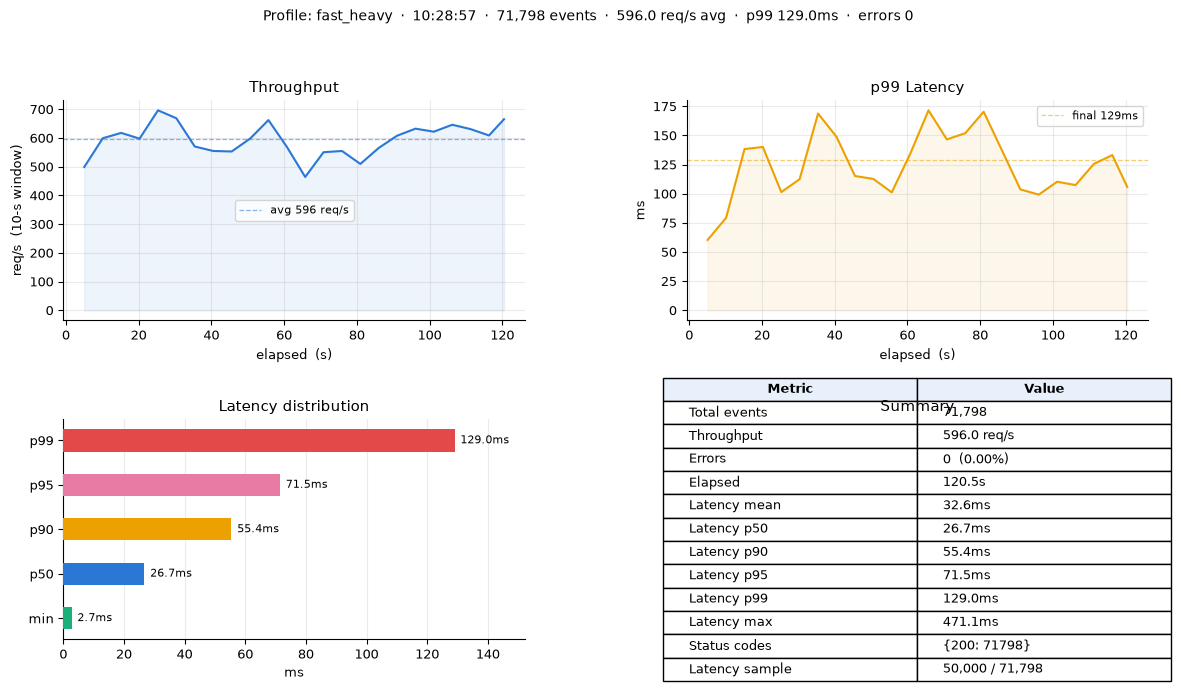

In [8]:
if "run_history" not in dir():
    run_history: list[dict] = []


# ── Loop helpers ───────────────────────────────────────────────

def _progress_line(elapsed: float, extra: str = "") -> None:
    ws = metrics.window_stats()
    print(
        f"  [{elapsed:7.1f}s] {metrics.total():>8,} total"
        f" | {ws['rps']:>7.1f} req/s"
        f" | p50={ws['p50']:.0f}ms p99={ws['p99']:.0f}ms"
        f" | errors={ws['errors']}"
        + (f"  {extra}" if extra else "")
    )


def _run_flat(t_start: float) -> None:
    last_print = last_snap = t_start
    while not _stop_event.is_set():
        time.sleep(0.5)
        now     = time.monotonic()
        elapsed = now - t_start
        if DURATION_SECONDS > 0 and elapsed >= DURATION_SECONDS:
            _stop_event.set(); break
        if TOTAL_EVENTS > 0 and _event_counter >= TOTAL_EVENTS:
            _stop_event.set(); break
        if now - last_snap >= 5:
            metrics.snapshot_log(elapsed)
            last_snap = now
        if now - last_print >= 5:
            remaining = ""
            if DURATION_SECONDS > 0:
                remaining = f"{max(DURATION_SECONDS - elapsed, 0):.0f}s left"
            elif TOTAL_EVENTS > 0:
                remaining = f"{max(TOTAL_EVENTS - _event_counter, 0)} events left"
            _progress_line(elapsed, remaining)
            last_print = now


def _run_ramp_saturation(session: requests.Session, t_start: float) -> None:
    step_interval = cfg.get("step_interval_seconds", 30)
    max_p99       = cfg.get("saturation_p99_ms", 100)
    max_threads   = NUM_THREADS
    active_count  = 0
    last_step     = t_start - step_interval
    last_print    = last_snap = t_start

    print(f"  Mode: +1 thread every {step_interval}s, stop when p99 > {max_p99}ms")

    while not _stop_event.is_set():
        time.sleep(0.5)
        now     = time.monotonic()
        elapsed = now - t_start

        if (now - last_step >= step_interval) and active_count < max_threads:
            active_count += 1
            t = threading.Thread(
                target=worker_fn, args=(f"ramp-{active_count}", 0, session, 0.0),
                daemon=True,
            )
            t.start()
            last_step = now
            print(f"  [{elapsed:7.1f}s] ▲ Thread {active_count} added")

        if now - last_snap >= 5:
            metrics.snapshot_log(elapsed)
            last_snap = now

        if now - last_print >= 5:
            ws        = metrics.window_stats()
            saturated = ws["p99"] > max_p99 and active_count >= 2
            _progress_line(elapsed, f"threads={active_count}" + (" ← SATURATED" if saturated else ""))
            if saturated:
                print(f"\n  ✖  Saturation at {active_count} threads"
                      f"  (p99 {ws['p99']:.0f}ms > {max_p99}ms)")
                _stop_event.set(); break
            last_print = now

        if active_count >= max_threads:
            ws = metrics.window_stats()
            print(f"\n  ✓  Reached max threads ({max_threads})"
                  f"  — p99={ws['p99']:.0f}ms  (threshold {max_p99}ms)")
            _stop_event.set(); break


def _run_spike(session: requests.Session, t_start: float) -> None:
    quiet_sec = cfg.get("spike_quiet_seconds", 60)
    burst_sec = cfg.get("spike_burst_seconds", 15)
    cycles    = cfg.get("spike_cycles", 3)
    last_snap = t_start

    for cycle in range(1, cycles + 1):
        if _stop_event.is_set():
            break

        print(f"\n  Cycle {cycle}/{cycles}: quiet phase ({quiet_sec}s)")
        phase_end = time.monotonic() + quiet_sec
        while time.monotonic() < phase_end and not _stop_event.is_set():
            time.sleep(2)
            now = time.monotonic()
            if now - last_snap >= 5:
                metrics.snapshot_log(now - t_start); last_snap = now
            _progress_line(now - t_start, "QUIET")

        if _stop_event.is_set():
            break

        print(f"  Cycle {cycle}/{cycles}: burst phase ({burst_sec}s, {NUM_THREADS} threads)")
        burst_stop    = threading.Event()
        burst_threads = []
        for i in range(NUM_THREADS):
            t = threading.Thread(
                target=worker_fn,
                args=(f"burst-{cycle}-{i}", 0, session, float(RATE_LIMIT_RPS)),
                kwargs={"local_stop": burst_stop},
                daemon=True,
            )
            burst_threads.append(t); t.start()

        phase_end = time.monotonic() + burst_sec
        while time.monotonic() < phase_end and not _stop_event.is_set():
            time.sleep(2)
            now = time.monotonic()
            if now - last_snap >= 2:
                metrics.snapshot_log(now - t_start); last_snap = now
            _progress_line(now - t_start, "BURST ▲")

        burst_stop.set()
        for t in burst_threads:
            t.join(timeout=3)

    _stop_event.set()


# ── Main entry point ───────────────────────────────────────────

def run_load_test() -> None:
    global _event_counter, _stop_event, metrics

    _event_counter = 0
    _stop_event    = threading.Event()
    metrics        = LoadTestMetrics()

    try:
        r = requests.get(f"{ACTUATOR}/health", timeout=5)
        if r.json().get("status") != "UP":
            print("ERROR: Backend health is not UP. Run: just up"); return
    except Exception as e:
        print(f"ERROR: Cannot reach backend: {e}\nRun: just up"); return

    print(f"\nStarting profile: {ACTIVE_PROFILE}")
    print(f"  {cfg['description']}")
    print("-" * 56)

    metrics.start()
    t_start    = time.monotonic()
    bg_threads: list[threading.Thread] = []
    bg_session = requests.Session()

    if BACKGROUND_THREADS > 0:
        print(f"  Background: {BACKGROUND_THREADS} × {BACKGROUND_RATE_RPS} req/s (starting now)")
        for i in range(BACKGROUND_THREADS):
            t = threading.Thread(
                target=worker_fn,
                args=(f"bg-{i}", 0, bg_session, float(BACKGROUND_RATE_RPS)),
                daemon=True,
            )
            bg_threads.append(t); t.start()

    session      = requests.Session()
    test_threads: list[threading.Thread] = []

    if ACTIVE_PROFILE == "ramp_saturation":
        _run_ramp_saturation(session, t_start)
    elif ACTIVE_PROFILE == "spike":
        _run_spike(session, t_start)
    else:
        for i in range(NUM_THREADS):
            delay = (RAMP_UP_SECONDS * i) / (NUM_THREADS - 1)                     if RAMP_UP_SECONDS > 0 and NUM_THREADS > 1 else 0.0
            t = threading.Thread(
                target=worker_fn,
                args=(f"worker-{i}", delay, session, float(RATE_LIMIT_RPS)),
                daemon=True,
            )
            test_threads.append(t); t.start()
        _run_flat(t_start)

    for t in test_threads + bg_threads:
        t.join(timeout=5)
    session.close()
    bg_session.close()
    metrics.stop()
    metrics.snapshot_log(metrics.elapsed())
    metrics.print_summary()

    run_history.append({
        "profile":   ACTIVE_PROFILE,
        "timestamp": datetime.now().strftime("%H:%M:%S"),
        "summary":   metrics.summary(),
        "log":       list(metrics._log),
    })

    print(f"\n  Run #{len(run_history)} saved.")

    # ── Render charts inline ───────────────────────────────────
    plot_run(run_history[-1])


run_load_test()

## §8 — Run History

Compare all runs recorded in this session.

In [9]:
# Text comparison table
compare_runs()

# Overlay chart — shows only when 2+ runs exist
plot_all_runs()

   #  Profile                     Time    Events    req/s     p50     p99    Errs
  ───────────────────────────────────────────────────────────────────────────────
   1  fast_heavy              10:28:57    71,798    596.0    26.7   129.0       0
Only one run recorded — use plot_run() instead.


## §9 — Post-Test Verification

Run after any test to confirm the pipeline processed all events.

In [10]:
print("Backend health:")
try:
    r      = requests.get(f"{ACTUATOR}/health", timeout=5)
    status = r.json().get("status", "UNKNOWN")
    icon   = "✓" if status == "UP" else "✖"
    print(f"  {icon}  Status: {status}")
except Exception as e:
    print(f"  ✖  Error: {e}")

print("\nConsumer metrics:")
try:
    r     = requests.get(
        f"{ACTUATOR}/metrics/auditflow.consumer.events.processed", timeout=5
    )
    value = r.json()["measurements"][0]["value"]
    print(f"  events.processed = {value:,.0f}")
except Exception as e:
    print(f"  Could not read metric: {e}")

print("\nRabbitMQ queue depth:")
try:
    queue = "labs64-audit-topic.labs64.io-auditflow"
    r     = requests.get(
        f"http://localhost:15673/api/queues/%2F/{queue}",
        auth=("guest", "guest"), timeout=5,
    )
    data  = r.json()
    ready = data["messages_ready"]
    unack = data.get("messages_unacknowledged", 0)
    icon  = "✓" if ready == 0 else "⚠"
    print(f"  {icon}  messages_ready          = {ready:,}")
    print(f"      messages_unacknowledged = {unack:,}")
    if ready > 0:
        print("  ⚠  Queue not fully drained — consumer may be falling behind.")
except Exception as e:
    print(f"  Could not check queue: {e}")

Backend health:
  ✓  Status: UP

Consumer metrics:
  events.processed = 34,716

RabbitMQ queue depth:
  ⚠  messages_ready          = 54,287
      messages_unacknowledged = 64
  ⚠  Queue not fully drained — consumer may be falling behind.
